# STEP 3 (Decision Tree) - Model Training
In this step, we're going to train Decision Tree for each personality trait and embedding.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt  
import seaborn as sns   
import numpy as np                                                                                                       
from sklearn.model_selection import train_test_split                                                                                                         
from sklearn.metrics import f1_score 
import joblib   
import os

from pipeline.smote_oversampling import SMOTEOversampler    
from pipeline.machine_learning_algorithms.decision_tree import DecisionTree


#### First, let's load the dataset and apply oversampling

In [3]:
df = pd.read_pickle('data/dataset_with_encodings/final_dataset_with_encodings.pkl')

In [4]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,posts_tfidf_features,posts_w2v_features,augmented_posts_tfidf_features,augmented_posts_w2v_features,I_E,N_S,T_F,J_P
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.039469853, -0.3728942, -0.41033414, -0.1154...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19693445, -0.0025032638, 0.08193041, 0.1530...",I,N,F,J
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.078822784, -0.31084794, -0.40682986, -0.102...","[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183...","[0.22643407, 0.13486987, 0.13359053, 0.1418835...",E,N,T,P
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.055956766, -0.31570536, -0.36344454, -0.075...","[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032...","[0.19347186, 0.021339012, 0.09674486, 0.159254...",I,N,T,P
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[-0.019194897, -0.37407914, -0.5568112, -0.182...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,...","[0.21894899, 0.21582802, 0.18478529, 0.2388864...",I,N,T,J
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.057541147, -0.29415804, -0.45218706, -0.204...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19203198, 0.121340014, -0.008840058, 0.0499...",E,N,T,J


TFIDF oversampling

In [5]:
X = np.stack(df["augmented_posts_tfidf_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                                                              
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [6]:
def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df  

In [7]:
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))                                                                

#### Now, We'll be training a model for TFIDF encodings

In [8]:
mbti_clf_tfidf = DecisionTree(                                                                                              
    random_state=42,                                                                  
    max_depth=15,                                    
    min_samples_split=5                                                                                                      
) 

In [9]:
mbti_clf_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅


In [10]:
mbti_clf_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.8513

              precision    recall  f1-score   support

           0       0.70      0.63      0.66       401
           1       0.89      0.92      0.90      1334

    accuracy                           0.85      1735
   macro avg       0.79      0.77      0.78      1735
weighted avg       0.85      0.85      0.85      1735


Evaluation for dimension: N_S
Accuracy: 0.8225

              precision    recall  f1-score   support

           0       0.38      0.47      0.42       240
           1       0.91      0.88      0.90      1495

    accuracy                           0.82      1735
   macro avg       0.65      0.67      0.66      1735
weighted avg       0.84      0.82      0.83      1735


Evaluation for dimension: T_F
Accuracy: 0.6496

              precision    recall  f1-score   support

           0       0.68      0.66      0.67       939
           1       0.61      0.64      0.63       796

    accuracy                       

In [11]:
os.makedirs("models/decision_tree", exist_ok=True)
for key, value in mbti_clf_tfidf.models.items():                                                                               
    caminho = f"models/decision_tree/{key}_tfidf_dt.pkl"                                                                          
    joblib.dump(value, caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/decision_tree/I_E_tfidf_dt.pkl
Salvo: models/decision_tree/N_S_tfidf_dt.pkl
Salvo: models/decision_tree/T_F_tfidf_dt.pkl
Salvo: models/decision_tree/J_P_tfidf_dt.pkl


#### Next, W2V encodings

W2V oversampling

In [12]:
X = np.stack(df["augmented_posts_w2v_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                        

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


In [13]:
def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df   

In [14]:
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

In [15]:
mbti_clf_w2v = DecisionTree(                                                                                              
    random_state=42,                                                                  
    max_depth=8,                                     
    min_samples_split=5                                                                                                      
)   

In [16]:
mbti_clf_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅


In [17]:
mbti_clf_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7677

              precision    recall  f1-score   support

           0       0.50      0.62      0.55       401
           1       0.88      0.81      0.84      1334

    accuracy                           0.77      1735
   macro avg       0.69      0.71      0.70      1735
weighted avg       0.79      0.77      0.78      1735


Evaluation for dimension: N_S
Accuracy: 0.7787

              precision    recall  f1-score   support

           0       0.34      0.64      0.44       240
           1       0.93      0.80      0.86      1495

    accuracy                           0.78      1735
   macro avg       0.64      0.72      0.65      1735
weighted avg       0.85      0.78      0.80      1735


Evaluation for dimension: T_F
Accuracy: 0.6380

              precision    recall  f1-score   support

           0       0.67      0.64      0.66       939
           1       0.60      0.64      0.62       796

    accuracy                       

In [18]:
os.makedirs("models/decision_tree", exist_ok=True)

for key, value in mbti_clf_w2v.models.items():                                                                               
    caminho = f"models/decision_tree/{key}_w2v_dt.pkl"                                                                          
    joblib.dump(value, caminho)                                                                                                  
    print(f"Salvo: {caminho}")

Salvo: models/decision_tree/I_E_w2v_dt.pkl
Salvo: models/decision_tree/N_S_w2v_dt.pkl
Salvo: models/decision_tree/T_F_w2v_dt.pkl
Salvo: models/decision_tree/J_P_w2v_dt.pkl


#### Let's train a model for the posts before the augmentation, just as a matter of comparison

In [19]:
X = np.stack(df["posts_tfidf_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                        

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)  

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)


In [20]:
mbti_clf_posts_tfidf = DecisionTree(                                                                                              
    random_state=42,                                                                  
    max_depth=8,                                     
    min_samples_split=5                                                                                                      
)  

In [21]:
mbti_clf_posts_tfidf.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅


In [22]:
mbti_clf_posts_tfidf.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.7504

              precision    recall  f1-score   support

           0       0.45      0.38      0.41       401
           1       0.82      0.86      0.84      1334

    accuracy                           0.75      1735
   macro avg       0.64      0.62      0.63      1735
weighted avg       0.74      0.75      0.74      1735


Evaluation for dimension: N_S
Accuracy: 0.8133

              precision    recall  f1-score   support

           0       0.31      0.28      0.29       240
           1       0.89      0.90      0.89      1495

    accuracy                           0.81      1735
   macro avg       0.60      0.59      0.59      1735
weighted avg       0.81      0.81      0.81      1735


Evaluation for dimension: T_F
Accuracy: 0.6058

              precision    recall  f1-score   support

           0       0.63      0.66      0.65       939
           1       0.58      0.54      0.56       796

    accuracy                       

In [23]:
for key, value in mbti_clf_posts_tfidf.models.items():                                                                               
    caminho = f"models/decision_tree/{key}_posts_tfidf_dt.pkl"                                                                          
    joblib.dump(value, caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/decision_tree/I_E_posts_tfidf_dt.pkl
Salvo: models/decision_tree/N_S_posts_tfidf_dt.pkl
Salvo: models/decision_tree/T_F_posts_tfidf_dt.pkl
Salvo: models/decision_tree/J_P_posts_tfidf_dt.pkl


In [24]:
X = np.stack(df["posts_w2v_features"].values)                                                              
y = df["type"] 

X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)        

smote = SMOTEOversampler(random_state=42)                        

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)  

def divide_mbti(y_series):                                                                                          
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df    
                                                                 
y_train_4cols = divide_mbti(y_train_balanced)                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


In [25]:
mbti_clf_posts_w2v = DecisionTree(                                                                                              
    random_state=42,                                                                  
    max_depth=8,                                     
    min_samples_split=5                                                                                                      
)   

In [26]:
mbti_clf_posts_w2v.fit(X_train_balanced, y_train_4cols)

Starting training process...
 -> Training model for dimension I_E...
 -> Training model for dimension N_S...
 -> Training model for dimension T_F...
 -> Training model for dimension J_P...
All 4 models trained successfully! ✅


In [27]:
mbti_clf_posts_w2v.evaluate(X_test, y_test_4cols)


Evaluation for dimension: I_E
Accuracy: 0.5885

              precision    recall  f1-score   support

           0       0.26      0.43      0.33       401
           1       0.79      0.64      0.70      1334

    accuracy                           0.59      1735
   macro avg       0.53      0.53      0.52      1735
weighted avg       0.67      0.59      0.62      1735


Evaluation for dimension: N_S
Accuracy: 0.6242

              precision    recall  f1-score   support

           0       0.19      0.51      0.27       240
           1       0.89      0.64      0.75      1495

    accuracy                           0.62      1735
   macro avg       0.54      0.58      0.51      1735
weighted avg       0.79      0.62      0.68      1735


Evaluation for dimension: T_F
Accuracy: 0.6709

              precision    recall  f1-score   support

           0       0.71      0.66      0.68       939
           1       0.63      0.69      0.66       796

    accuracy                       

In [28]:
for key, value in mbti_clf_posts_w2v.models.items():                                                                               
    caminho = f"models/decision_tree/{key}_posts_w2v_dt.pkl"                                                                          
    joblib.dump(value, caminho)                                                                                                  
    print(f"Salvo: {caminho}")  

Salvo: models/decision_tree/I_E_posts_w2v_dt.pkl
Salvo: models/decision_tree/N_S_posts_w2v_dt.pkl
Salvo: models/decision_tree/T_F_posts_w2v_dt.pkl
Salvo: models/decision_tree/J_P_posts_w2v_dt.pkl


#### Finally, the results of them 

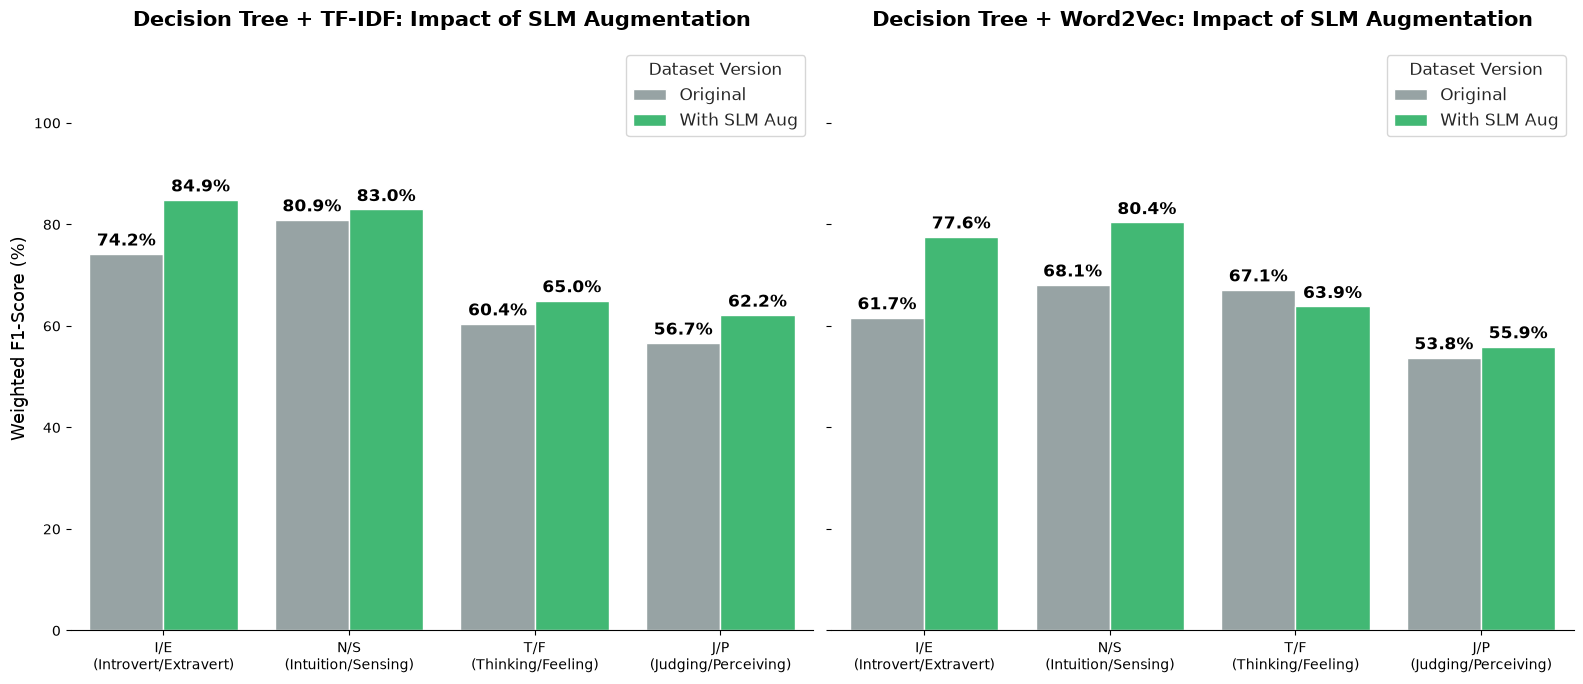

In [29]:
# ==========================================                                                                                   
# 1. Recreating the Original Test Data                                                                                         
# ==========================================                                                                                   
y = df["type"]                                                                                                                 
                                                                                                                               
# TF-IDF (Augmented and Original)                                                                                              
X_tfidf_aug = np.stack(df["augmented_posts_tfidf_features"].values)                                                            
_, X_test_tfidf_aug, _, y_test = train_test_split(X_tfidf_aug, y, test_size=0.2, random_state=42, stratify=y)                  
                                                                                                                               
X_tfidf_orig = np.stack(df["posts_tfidf_features"].values)                                                                     
_, X_test_tfidf_orig, _, _ = train_test_split(X_tfidf_orig, y, test_size=0.2, random_state=42, stratify=y)                     
                                                                                                                               
# W2V (Augmented and Original)                                                                                                 
X_w2v_aug = np.stack(df["augmented_posts_w2v_features"].values)                                                                
_, X_test_w2v_aug, _, _ = train_test_split(X_w2v_aug, y, test_size=0.2, random_state=42, stratify=y)                           
                                                                                                                               
X_w2v_orig = np.stack(df["posts_w2v_features"].values)                                                                         
_, X_test_w2v_orig, _, _ = train_test_split(X_w2v_orig, y, test_size=0.2, random_state=42, stratify=y)                         
                                                                                                                               
y_test_4cols = divide_mbti(y_test.reset_index(drop=True))                                                                      
                                                                                                                               
# ==========================================                                                                                   
# 2. Generating Predictions                                                                                                    
# ==========================================                                                                                   
pred_tfidf_aug = mbti_clf_tfidf.predict(X_test_tfidf_aug)                                                                      
pred_tfidf_orig = mbti_clf_posts_tfidf.predict(X_test_tfidf_orig)                                                              
                                                                                                                               
pred_w2v_aug = mbti_clf_w2v.predict(X_test_w2v_aug)                                                                            
pred_w2v_orig = mbti_clf_posts_w2v.predict(X_test_w2v_orig)                                                                    
                                                                                                                               
# ==========================================                                                                                   
# 3. Calculating Metrics                                                                                                       
# ==========================================                                                                                   
colunas = ['I_E', 'N_S', 'T_F', 'J_P']                                                                                         
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)',                            
'J/P\n(Judging/Perceiving)']                                                                                                     
                                                                                                                               
dados = []                                                                                                                     
for i, col in enumerate(colunas):                                                                                              
    # TF-IDF                                                                                                                   
    f1_t_aug = f1_score(y_test_4cols[col], pred_tfidf_aug[col], average='weighted') * 100                                      
    f1_t_orig = f1_score(y_test_4cols[col], pred_tfidf_orig[col], average='weighted') * 100                                    
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_orig, 'Augmentation': 'Original', 'Embedding': 'TF-IDF'})             
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_t_aug, 'Augmentation': 'With SLM Aug', 'Embedding': 'TF-IDF'})          
                                                                                                                               
    # Word2Vec                                                                                                                 
    f1_w_aug = f1_score(y_test_4cols[col], pred_w2v_aug[col], average='weighted') * 100                                        
    f1_w_orig = f1_score(y_test_4cols[col], pred_w2v_orig[col], average='weighted') * 100                                      
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_orig, 'Augmentation': 'Original', 'Embedding': 'Word2Vec'})           
    dados.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_w_aug, 'Augmentation': 'With SLM Aug', 'Embedding': 'Word2Vec'})        
                                                                                                                               
df_plot = pd.DataFrame(dados)                                                                                                  
                                                                                                                               
# ==========================================                                                                                   
# 4. Building the Plots                                                                                                        
# ==========================================                                                                                   
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)                                                                   
sns.set_theme(style="whitegrid")                                                                                               
paleta = ['#95a5a6', '#2ecc71']                                                                                                
                                                                                                                               
# Panel 1: TF-IDF
sns.barplot(data=df_plot[df_plot['Embedding'] == 'TF-IDF'], x='Axis', y='F1 (%)', hue='Augmentation', palette=paleta,          
ax=axes[0])
axes[0].set_title("Decision Tree + TF-IDF: Impact of SLM Augmentation", fontsize=15, fontweight='bold', pad=15)                                
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[0].set_xlabel("")
  
# Panel 2: Word2Vec
sns.barplot(data=df_plot[df_plot['Embedding'] == 'Word2Vec'], x='Axis', y='F1 (%)', hue='Augmentation', palette=paleta,        
ax=axes[1])
axes[1].set_title("Decision Tree + Word2Vec: Impact of SLM Augmentation", fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
  
# Formatting Data Labels and Legends
for ax in axes:
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%", (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='baseline', fontsize=12, fontweight='bold', color='black', 
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Dataset Version', fontsize='12', loc='upper right')
  
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()